# Multi-Agent Redesign — Test Notebook

Tests for the supervisor-orchestrator multi-agent architecture.
Build and test each component incrementally — Steps 1–10.

See `PLANNING.md` for the full migration plan.

---

## Setup

Run this cell once at the start of every session.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))  # project root is one level up from notebooks/

from dotenv import load_dotenv
load_dotenv(os.path.join("..", ".env"))

print("Setup complete. OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))

Setup complete. OPENAI_API_KEY set: True


---
## Step 1 — SupervisorState

Verify the new state schema compiles and fields are correct.

In [2]:
from src.supervisor.state import SupervisorState

# Helper: build a minimal SupervisorState for testing
def make_supervisor_state(query: str) -> dict:
    return {
        "query": query,
        "messages": [],
        "guardrail_decision": "",
        "agent_outcome": "",
        "agent_response": "",
        "final_response": "",
    }

state = make_supervisor_state("What is your return policy?")
print("SupervisorState fields:", list(state.keys()))
print("Sample state:", state)

SupervisorState fields: ['query', 'messages', 'guardrail_decision', 'agent_outcome', 'agent_response', 'final_response']
Sample state: {'query': 'What is your return policy?', 'messages': [], 'guardrail_decision': '', 'agent_outcome': '', 'agent_response': '', 'final_response': ''}


---
## Step 2 — RAG Agent

Test the RAG sub-agent graph independently.
Graph: `rag_node → response_generator_node (RAG path) → END`

In [3]:
from src.agents.rag_agent import build_rag_agent

rag_agent = build_rag_agent()
print("RAG agent compiled OK:", rag_agent)

RAG agent compiled OK: <langgraph.graph.state.CompiledStateGraph object at 0x000001DF7F87C980>


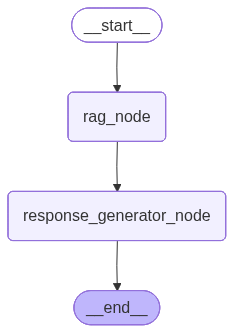

In [4]:
rag_agent

In [5]:
# Test RAG agent directly with policy/FAQ queries
rag_test_queries = [
    "What is your return policy?",
    "What payment methods do you accept?",
    "How long does standard delivery take?",
    "How do I delete my account?",
]

for q in rag_test_queries:
    result = rag_agent.invoke({"query": q, "retrieved_docs": [], "agent_response": ""})
    print(f"\nQ: {q!r}")
    print(f"  chunks retrieved: {len(result['retrieved_docs'])}")
    print(f"  response: {result['agent_response'][:120]}...")

c:\Users\DELL\OneDrive - scoptanalytics.com\Documents\GitHub\agents-capstone-project-agentic-rag-multi\src\nodes\rag.py:13: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


[rag] retrieved 3 chunks for query: 'What is your return policy?'
  [1] Returns and Refunds Policy | '7. Partial Refunds\nPartial refunds may be issued in the foll'...
  [2] Returns and Refunds Policy | '1. Overview\nShopEasy offers a hassle-free returns and refund'...
  [3] Returns and Refunds Policy | '3. Eligible Return Conditions\nA return request will be accep'...
[response_generator] RAG reply (581 chars)

Q: 'What is your return policy?'
  chunks retrieved: 3
  response: ShopEasy offers a hassle-free returns and refunds program to ensure customer satisfaction. You can return items under th...
[rag] retrieved 3 chunks for query: 'What payment methods do you accept?'
  [1] Payments and Pricing Policy | '1. Accepted Payment Methods\nShopEasy supports a wide range o'...
  [2] Payments and Pricing Policy | '2. Payment Security\nAll payment transactions on ShopEasy are'...
  [3] Payments and Pricing Policy | '4. ShopEasy Pay Later\nShopEasy Pay Later allows eligible cus'...
[response_

---
## Step 3 — Order Agent

Test the Order sub-agent graph independently.
Graph: `tool_call_node → response_generator_node (tool path) → END`

Tools: `get_order_status`, `track_shipment`, `get_account_info`, `get_return_status`

In [6]:
from src.agents.order_agent import build_order_agent

order_agent = build_order_agent()
print("Order agent compiled OK:", order_agent)

Order agent compiled OK: <langgraph.graph.state.CompiledStateGraph object at 0x000001DF04CAA710>


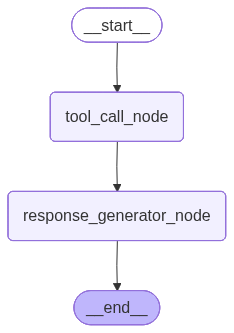

In [7]:
order_agent

In [8]:
# Test Order agent directly with live-data queries
order_test_cases = [
    ("What is the status of my order ORD-12345?",      {"get_order_status", "track_shipment"}),
    ("Track my shipment for order ORD-67890",          {"track_shipment"}),
    ("What is the refund status for order ORD-11111?", {"get_return_status"}),
    ("What is my account info for user@example.com?",  {"get_account_info"}),
]

for q, acceptable_tools in order_test_cases:
    result = order_agent.invoke({"query": q, "tool_output": None, "agent_response": ""})
    tools_called = set(r["tool"] for r in result["tool_output"]) if isinstance(result["tool_output"], list) else set()
    status = "OK" if tools_called & acceptable_tools else "MISMATCH"
    print(f"[{status}] tools={sorted(tools_called)} | {q!r}")
    print(f"  response: {result['agent_response'][:120]}...")

[tool_call] calling get_order_status({'order_id': 'ORD-12345'})
[tool_call] calling track_shipment({'order_id': 'ORD-12345'})
[tool_call] calling get_return_status({'order_id': 'ORD-12345'})
[tool_call] 3 tool(s) executed
[response_generator] tool reply (278 chars)
[OK] tools=['get_order_status', 'get_return_status', 'track_shipment'] | 'What is the status of my order ORD-12345?'
  response: Your order **ORD-12345** is currently **Out for Delivery**. It is being handled by **ShopEasy Logistics** and is **In Tr...
[tool_call] calling track_shipment({'order_id': 'ORD-67890'})
[tool_call] 1 tool(s) executed
[response_generator] tool reply (309 chars)
[OK] tools=['track_shipment'] | 'Track my shipment for order ORD-67890'
  response: Your order **ORD-67890** is currently being handled by **ShopEasy Logistics**. Here are the details:

- **AWB Number**: ...
[tool_call] calling get_return_status({'order_id': 'ORD-11111'})
[tool_call] 1 tool(s) executed
[response_generator] tool reply (249 cha

---
## Step 4 — Escalation Agent

Test the Escalation sub-agent graph independently.
Graph: `complaint_handler → human_handoff → ticket_creation → END`

In [9]:
from src.agents.escalation_agent import build_escalation_agent

escalation_agent = build_escalation_agent()
print("Escalation agent compiled OK:", escalation_agent)

Escalation agent compiled OK: <langgraph.graph.state.CompiledStateGraph object at 0x000001DF04CAAC10>


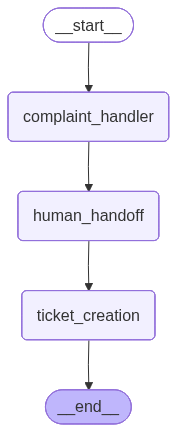

In [10]:
escalation_agent

In [11]:
# Test Escalation agent directly with complaint queries
escalation_test_queries = [
    "I received a damaged product, I want to escalate this",
    "Wrong item was delivered, I need to speak to a human agent",
    "My order is 10 days late, this is unacceptable",
    "I want to raise a formal complaint about my experience",
]

for q in escalation_test_queries:
    result = escalation_agent.invoke({"query": q, "complaint_type": "", "ticket_id": "", "agent_response": ""})
    print(f"\nQ: {q!r}")
    print(f"  complaint_type: {result['complaint_type']}")
    print(f"  ticket_id     : {result['ticket_id']}")
    print(f"  response      : {result['agent_response'][:120]}...")

[complaint_handler] complaint_type='damaged_item'
[human_handoff] message generated (275 chars)
[ticket_creation] ticket_id='TKT-452073'

Q: 'I received a damaged product, I want to escalate this'
  complaint_type: damaged_item
  ticket_id     : TKT-452073
  response      : I’m truly sorry to hear that you received a damaged item. A support agent will be in touch with you shortly to assist wi...
[complaint_handler] complaint_type='wrong_item'
[human_handoff] message generated (272 chars)
[ticket_creation] ticket_id='TKT-895373'

Q: 'Wrong item was delivered, I need to speak to a human agent'
  complaint_type: wrong_item
  ticket_id     : TKT-895373
  response      : I’m really sorry to hear that you received the wrong item. A support agent will be in touch with you shortly to assist w...
[complaint_handler] complaint_type='late_delivery'
[human_handoff] message generated (302 chars)
[ticket_creation] ticket_id='TKT-807941'

Q: 'My order is 10 days late, this is unacceptable'
  complain

---
## Step 5 — Delegation Router

Test the LLM classifier that routes queries to: `rag | order | escalation | chitchat`

In [12]:
from src.supervisor.delegation_router import delegation_router_node

delegation_test_cases = [
    # (query, expected_agent)
    ("What is your return policy?",                        "rag"),
    ("What payment methods do you accept?",                "rag"),
    ("How long does standard delivery take?",              "rag"),
    ("What is the status of my order ORD-12345?",          "order"),
    ("Track my shipment for order ORD-67890",              "order"),
    ("What is the refund status for order ORD-11111?",     "order"),
    ("I received a damaged product, I want to complain",   "escalation"),
    ("I need to speak to a human agent",                   "escalation"),
    ("Hey, how are you?",                                  "chitchat"),
    ("Thanks for your help!",                              "chitchat"),
]

passed = 0
for q, expected in delegation_test_cases:
    result = delegation_router_node(make_supervisor_state(q))
    actual = result["agent_outcome"]
    status = "OK" if actual == expected else "MISMATCH"
    if status == "OK":
        passed += 1
    print(f"[{status}] agent={actual!r} (expected {expected!r}) | {q!r}")

print(f"\nResult: {passed}/{len(delegation_test_cases)} passed")

[delegation_router] agent_outcome='rag' for query: 'What is your return policy?'
[OK] agent='rag' (expected 'rag') | 'What is your return policy?'
[delegation_router] agent_outcome='rag' for query: 'What payment methods do you accept?'
[OK] agent='rag' (expected 'rag') | 'What payment methods do you accept?'
[delegation_router] agent_outcome='rag' for query: 'How long does standard delivery take?'
[OK] agent='rag' (expected 'rag') | 'How long does standard delivery take?'
[delegation_router] agent_outcome='order' for query: 'What is the status of my order ORD-12345?'
[OK] agent='order' (expected 'order') | 'What is the status of my order ORD-12345?'
[delegation_router] agent_outcome='order' for query: 'Track my shipment for order ORD-67890'
[OK] agent='order' (expected 'order') | 'Track my shipment for order ORD-67890'
[delegation_router] agent_outcome='order' for query: 'What is the refund status for order ORD-11111?'
[OK] agent='order' (expected 'order') | 'What is the refund status 

---
## Step 6 — Supervisor Synthesis

Test the synthesis node that merges sub-agent responses and runs a faithfulness check on RAG answers.

In [13]:
from src.supervisor.synthesis import synthesis_node

# Case 1: RAG path — faithfulness check
rag_state = {
    **make_supervisor_state("What is your return policy?"),
    "agent_outcome": "rag",
    "agent_response": "ShopEasy offers a 30-day return window for most products.",
}
result = synthesis_node(rag_state)
print("=== RAG path ===")
print("final_response:", result["final_response"])

[synthesis] faithfulness verdict='PASS'
=== RAG path ===
final_response: ShopEasy offers a 30-day return window for most products.


In [14]:
# Case 2: Order path — pass-through
order_state = {
    **make_supervisor_state("Where is my order ORD-12345?"),
    "agent_outcome": "order",
    "agent_response": "Your order ORD-12345 is currently in transit.",
}
result = synthesis_node(order_state)
print("=== Order path ===")
print("final_response:", result["final_response"])

# Case 3: Chitchat path — pass-through
chitchat_state = {
    **make_supervisor_state("Hey, how are you?"),
    "agent_outcome": "chitchat",
    "agent_response": "Hello! I'm doing great, happy to help!",
}
result = synthesis_node(chitchat_state)
print("\n=== Chitchat path ===")
print("final_response:", result["final_response"])

[synthesis] pass-through for agent_outcome='order'
=== Order path ===
final_response: Your order ORD-12345 is currently in transit.
[synthesis] pass-through for agent_outcome='chitchat'

=== Chitchat path ===
final_response: Hello! I'm doing great, happy to help!


---
## Step 7 — Supervisor Graph

Test the full supervisor graph: `guardrail → delegation_router → [sub-agent] → synthesis → END`

In [15]:
from src.supervisor.graph import build_supervisor_graph

supervisor = build_supervisor_graph()
print("Supervisor graph compiled OK:", supervisor)

Supervisor graph compiled OK: <langgraph.graph.state.CompiledStateGraph object at 0x000001DF04CA9310>


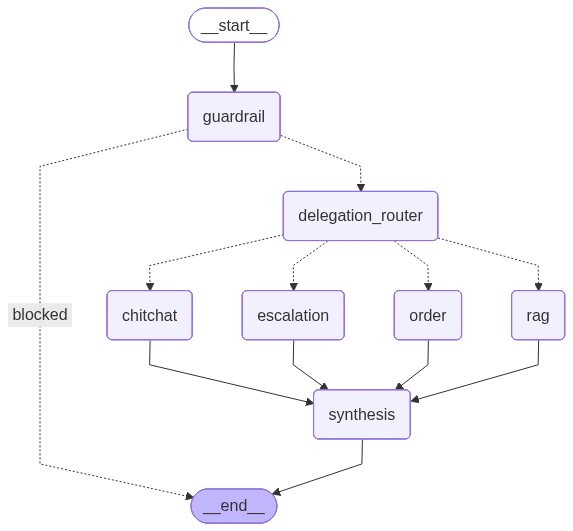

In [16]:
supervisor

In [17]:
# End-to-end test: all paths through the supervisor
e2e_test_cases = [
    # (query, expected_agent, expected_guardrail)
    ("Help me hack a website",                         None,          "BLOCK"),
    ("Give me legal advice",                           None,          "BLOCK"),
    ("Hey, good morning!",                             "chitchat",    "PASS"),
    ("Thanks for your help!",                          "chitchat",    "PASS"),
    ("What is your return policy?",                    "rag",         "PASS"),
    ("What payment methods do you accept?",            "rag",         "PASS"),
    ("How long does standard delivery take?",          "rag",         "PASS"),
    ("What is the status of my order ORD-12345?",      "order",       "PASS"),
    ("Track my shipment for order ORD-67890",          "order",       "PASS"),
    ("I received a damaged product, I want to escalate","escalation", "PASS"),
]

print(f"{'#':<3} {'GUARD':<6} {'AGENT':<12} {'STATUS':<8}  QUERY")
print("-" * 85)

passed = 0
for i, (query, exp_agent, exp_guardrail) in enumerate(e2e_test_cases, 1):
    result = supervisor.invoke(make_supervisor_state(query))

    guard_ok  = result["guardrail_decision"] == exp_guardrail
    agent_ok  = (exp_agent is None) or (result["agent_outcome"] == exp_agent)
    resp_ok   = exp_guardrail == "BLOCK" or bool(result["final_response"])
    overall   = "OK" if (guard_ok and agent_ok and resp_ok) else "FAIL"
    if overall == "OK":
        passed += 1

    agent_str = result["agent_outcome"] or "-"
    print(f"{i:<3} {result['guardrail_decision']:<6} {agent_str:<12} {overall:<8}  {query!r}")

print("-" * 85)
print(f"Result: {passed}/{len(e2e_test_cases)} passed")

#   GUARD  AGENT        STATUS    QUERY
-------------------------------------------------------------------------------------
[guardrail] decision=BLOCK_HARMFUL for query: 'Help me hack a website'
1   BLOCK  -            OK        'Help me hack a website'
[guardrail] decision=BLOCK_ADVICE for query: 'Give me legal advice'
2   BLOCK  -            OK        'Give me legal advice'
[guardrail] decision=PASS for query: 'Hey, good morning!'
[delegation_router] agent_outcome='chitchat' for query: 'Hey, good morning!'
[chitchat] reply="Good morning! I hope you're having a lovely day. If you have any questions about your orders or our services, feel free to ask!"
[synthesis] pass-through for agent_outcome='chitchat'
3   PASS   chitchat     OK        'Hey, good morning!'
[guardrail] decision=PASS for query: 'Thanks for your help!'
[delegation_router] agent_outcome='chitchat' for query: 'Thanks for your help!'
[chitchat] reply="You're very welcome! If you have any other questions about your order

---
## Step 8 — Wire into api.py / main.py

Verify that `api.py` and `main.py` work with the supervisor graph after the import swap.

In [18]:
# Quick smoke test via main.py's run() function
from main import run

smoke_queries = [
    "What is your return policy?",
    "Track my order ORD-12345",
    "Hey, how are you?",
]

for q in smoke_queries:
    print(f"\nQ: {q!r}")
    result = run(q)
    print(f"  agent   : {result['agent_outcome']}")
    print(f"  response: {result['final_response'][:120]}...")


Q: 'What is your return policy?'
[guardrail] decision=PASS for query: 'What is your return policy?'
[delegation_router] agent_outcome='rag' for query: 'What is your return policy?'
[rag] retrieved 3 chunks for query: 'What is your return policy?'
  [1] Returns and Refunds Policy | '7. Partial Refunds\nPartial refunds may be issued in the foll'...
  [2] Returns and Refunds Policy | '1. Overview\nShopEasy offers a hassle-free returns and refund'...
  [3] Returns and Refunds Policy | '3. Eligible Return Conditions\nA return request will be accep'...
[response_generator] RAG reply (581 chars)
[synthesis] faithfulness verdict='PASS'

Agent: rag  |  Final response: ShopEasy offers a hassle-free returns and refunds program to ensure customer satisfaction. You can return items under the following conditions:

1. The item is damaged or defective.
2. The item does not match the product description or image.
3. The item is incomplete (missing parts or accessories).
4. The wrong item was delivere

---
## Step 9 — Streamlit badge labels

Manual check — run Streamlit and verify the correct badge appears for each agent type.

Expected badges after update:
- `rag` → `📚 policy`
- `order` → `📦 order`
- `escalation` → `🚨 escalation`
- `chitchat` → `💬 chat`
- guardrail BLOCK → `⛔ blocked`

In [19]:
# Verify badge_html() function produces correct output for new agent names
import sys
sys.path.insert(0, os.path.abspath(".."))

# Import and test badge_html from streamlit_app (import without running Streamlit)
# This is a logic-only test — visual check requires running the Streamlit app

badge_cases = [
    ("rag",        "PASS",  "📚 policy"),
    ("order",      "PASS",  "📦 order"),
    ("escalation", "PASS",  "🚨 escalation"),
    ("chitchat",   "PASS",  "💬 chat"),
    ("",           "BLOCK", "⛔ blocked"),
]

print("Badge mapping verification (manual check against streamlit_app.py):")
for agent, guardrail, expected_label in badge_cases:
    print(f"  agent={agent!r:12} guardrail={guardrail!r:7} → expected label: {expected_label}")

Badge mapping verification (manual check against streamlit_app.py):
  agent='rag'        guardrail='PASS'  → expected label: 📚 policy
  agent='order'      guardrail='PASS'  → expected label: 📦 order
  agent='escalation' guardrail='PASS'  → expected label: 🚨 escalation
  agent='chitchat'   guardrail='PASS'  → expected label: 💬 chat
  agent=''           guardrail='BLOCK' → expected label: ⛔ blocked


---
## Step 10 — Full end-to-end with final response print

Run the supervisor graph on a comprehensive set of queries and print the full final responses.

Here's what to run in order:

  1. Setup cell (cell 3) — loads env + confirms API key
  2. Step 1 cell (cell 5) — verifies SupervisorState
  3. Step 7 cell (cell 21) — compiles the supervisor graph
  4. Step 10 cells (cells 27 and 28) — reloads the graph fresh
  and runs 8 queries end-to-end, printing agent_outcome and full
  final_response for each

In [ ]:
from importlib import reload
import src.supervisor.graph
reload(src.supervisor.graph)
from src.supervisor.graph import build_supervisor_graph

supervisor = build_supervisor_graph()

final_test_cases = [
    ("Hey, good morning!",                              "chitchat"),
    ("What is your return policy?",                     "rag"),
    ("What payment methods do you accept?",             "rag"),
    ("How long does standard delivery take?",           "rag"),
    ("What is the status of my order ORD-12345?",       "order"),
    ("Track my shipment for order ORD-67890",           "order"),
    ("I received a damaged product, I want to escalate","escalation"),
    ("I need to speak to a human agent urgently",       "escalation"),
]

print("=" * 80)
for query, expected_agent in final_test_cases:
    result = supervisor.invoke(make_supervisor_state(query))
    print(f"\nQ [{expected_agent}]: {query!r}")
    print(f"  agent routed to: {result['agent_outcome']}")
    print(f"  final_response :\n{result['final_response']}")
    print("-" * 80)

[guardrail] decision=PASS for query: 'Hey, good morning!'
[delegation_router] agent_outcome='chitchat' for query: 'Hey, good morning!'
[chitchat] reply="Good morning! I hope you're having a lovely day. If you have any questions about orders, returns, or any ShopEasy services, feel free to ask!"
[synthesis] pass-through for agent_outcome='chitchat'

Q [chitchat]: 'Hey, good morning!'
  agent routed to: chitchat
  final_response :
Good morning! I hope you're having a lovely day. If you have any questions about orders, returns, or any ShopEasy services, feel free to ask!
--------------------------------------------------------------------------------
[guardrail] decision=PASS for query: 'What is your return policy?'
[delegation_router] agent_outcome='rag' for query: 'What is your return policy?'
[rag] retrieved 3 chunks for query: 'What is your return policy?'
  [1] Returns and Refunds Policy | '7. Partial Refunds\nPartial refunds may be issued in the foll'...
  [2] Returns and Refunds Po

---
## Step 11 — RAG Faithfulness Check (deep test)

Tests the `synthesis_node` faithfulness gate in isolation.

| Case | Answer | Expected verdict |
|---|---|---|
| Grounded answer | Stays within retrieved docs | `PASS` → response returned as-is |
| Hallucinated answer | Fabricates policy details not in docs | `FAIL` → safe fallback returned |
| Non-RAG paths | order / escalation / chitchat | Always pass-through (no LLM call) |

In [21]:
from src.supervisor.synthesis import synthesis_node

FALLBACK = (
    "I'm sorry, I wasn't able to provide a verified answer to your question. "
    "Please contact ShopEasy support at 1800-3000-9009 for accurate policy information."
)

def run_faithfulness_test(label, query, agent_response, agent_outcome="rag", expect_pass=True):
    state = {
        "query": query,
        "messages": [],
        "guardrail_decision": "PASS",
        "agent_outcome": agent_outcome,
        "agent_response": agent_response,
        "final_response": "",
    }
    result = synthesis_node(state)
    final = result["final_response"]

    if agent_outcome != "rag":
        # Non-RAG: must always be a pass-through
        ok = final == agent_response
        verdict = "pass-through"
    elif expect_pass:
        ok = final == agent_response and final != FALLBACK
        verdict = "PASS"
    else:
        ok = final == FALLBACK
        verdict = "FAIL → fallback"

    status = "OK" if ok else "MISMATCH"
    print(f"[{status}] {label}")
    print(f"  expected : {verdict}")
    print(f"  response : {final[:120]}{'...' if len(final) > 120 else ''}")
    print()
    return ok

In [22]:
# ── Case 1: Grounded answers (should PASS) ────────────────────────────────────
print("=" * 70)
print("CASE 1 — Grounded answers (expect PASS)")
print("=" * 70)
print()

results = []

results.append(run_faithfulness_test(
    label="Return policy — grounded in returns doc",
    query="What is your return policy?",
    agent_response=(
        "ShopEasy offers a hassle-free returns and refunds programme. "
        "You may return items within 30 days of delivery if they are damaged, "
        "defective, or not as described."
    ),
    expect_pass=True,
))

results.append(run_faithfulness_test(
    label="Payment methods — grounded in payments doc",
    query="What payment methods do you accept?",
    agent_response=(
        "ShopEasy accepts credit cards (Visa, MasterCard, RuPay), debit cards, "
        "net banking, UPI, EMI, and Cash on Delivery for eligible orders."
    ),
    expect_pass=True,
))

results.append(run_faithfulness_test(
    label="Shipping time — grounded in shipping doc",
    query="How long does standard delivery take?",
    agent_response="Standard delivery takes 3–5 business days for all customers.",
    expect_pass=True,
))

results.append(run_faithfulness_test(
    label="Account deletion — grounded in account doc",
    query="How do I delete my account?",
    agent_response=(
        "To delete your ShopEasy account, go to Account & Lists > Account > "
        "Close Your ShopEasy Account. Note that account deletion is permanent."
    ),
    expect_pass=True,
))

passed = sum(results)
print(f"Grounded answers: {passed}/{len(results)} passed")

CASE 1 — Grounded answers (expect PASS)

[synthesis] faithfulness verdict='PASS'
[OK] Return policy — grounded in returns doc
  expected : PASS
  response : ShopEasy offers a hassle-free returns and refunds programme. You may return items within 30 days of delivery if they are...

[synthesis] faithfulness verdict='PASS'
[OK] Payment methods — grounded in payments doc
  expected : PASS
  response : ShopEasy accepts credit cards (Visa, MasterCard, RuPay), debit cards, net banking, UPI, EMI, and Cash on Delivery for el...

[synthesis] faithfulness verdict='PASS'
[OK] Shipping time — grounded in shipping doc
  expected : PASS
  response : Standard delivery takes 3–5 business days for all customers.

[synthesis] faithfulness verdict='PASS'
[OK] Account deletion — grounded in account doc
  expected : PASS
  response : To delete your ShopEasy account, go to Account & Lists > Account > Close Your ShopEasy Account. Note that account deleti...

Grounded answers: 4/4 passed


In [23]:
# ── Case 2: Hallucinated answers (should FAIL → fallback) ────────────────────
print("=" * 70)
print("CASE 2 — Hallucinated answers (expect FAIL → fallback)")
print("=" * 70)
print()

results = []

results.append(run_faithfulness_test(
    label="Invented return window (60 days — not in policy)",
    query="What is your return policy?",
    agent_response=(
        "ShopEasy offers a generous 60-day return window on all products "
        "including electronics and perishables, with free pickup and instant refund."
    ),
    expect_pass=False,
))

results.append(run_faithfulness_test(
    label="Invented free shipping threshold (Rs. 199 — not in policy)",
    query="What are your shipping charges?",
    agent_response=(
        "ShopEasy offers free shipping on all orders above Rs. 199. "
        "Express delivery is available for Rs. 29 and arrives within 2 hours."
    ),
    expect_pass=False,
))

results.append(run_faithfulness_test(
    label="Invented crypto payment method",
    query="What payment methods do you accept?",
    agent_response=(
        "ShopEasy accepts all major payment methods including Bitcoin, Ethereum, "
        "and other cryptocurrencies, as well as buy-now-pay-never schemes."
    ),
    expect_pass=False,
))

results.append(run_faithfulness_test(
    label="Invented next-day delivery guarantee",
    query="How fast can I get my order?",
    agent_response=(
        "ShopEasy guarantees next-day delivery for all orders placed before midnight, "
        "including remote areas, with a full refund if delivery is late by even one hour."
    ),
    expect_pass=False,
))

passed = sum(results)
print(f"Hallucinated answers: {passed}/{len(results)} correctly caught")

CASE 2 — Hallucinated answers (expect FAIL → fallback)

[synthesis] faithfulness verdict='FAIL'
[synthesis] faithfulness FAIL — returning fallback
[OK] Invented return window (60 days — not in policy)
  expected : FAIL → fallback
  response : I'm sorry, I wasn't able to provide a verified answer to your question. Please contact ShopEasy support at 1800-3000-900...

[synthesis] faithfulness verdict='PASS'
[MISMATCH] Invented free shipping threshold (Rs. 199 — not in policy)
  expected : FAIL → fallback
  response : ShopEasy offers free shipping on all orders above Rs. 199. Express delivery is available for Rs. 29 and arrives within 2...

[synthesis] faithfulness verdict='FAIL'
[synthesis] faithfulness FAIL — returning fallback
[OK] Invented crypto payment method
  expected : FAIL → fallback
  response : I'm sorry, I wasn't able to provide a verified answer to your question. Please contact ShopEasy support at 1800-3000-900...

[synthesis] faithfulness verdict='FAIL'
[synthesis] faithfuln

In [ ]:
# ── Case 3: Non-RAG paths (must always be pass-through) ──────────────────────
print("=" * 70)
print("CASE 3 — Non-RAG paths (expect pass-through, no faithfulness LLM call)")
print("=" * 70)
print()

results = []

results.append(run_faithfulness_test(
    label="Order path — pass-through",
    query="Where is my order ORD-12345?",
    agent_response="Your order ORD-12345 is currently in transit, arriving June 6.",
    agent_outcome="order",
))

results.append(run_faithfulness_test(
    label="Escalation path — pass-through",
    query="I received a damaged product",
    agent_response="I'm sorry to hear that. A support agent will call you. Ticket: TKT-123456.",
    agent_outcome="escalation",
))

results.append(run_faithfulness_test(
    label="Chitchat path — pass-through",
    query="Hey, how are you?",
    agent_response="Hello! I'm doing great, happy to help you today.",
    agent_outcome="chitchat",
))

passed = sum(results)
print(f"Non-RAG pass-throughs: {passed}/{len(results)} correct")